In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
with open("./data/classification_meta.yaml", "r") as file:
    meta = yaml.safe_load(file)
with open("./data/regression_meta.yaml", "r") as file:
    meta.update(yaml.safe_load(file))

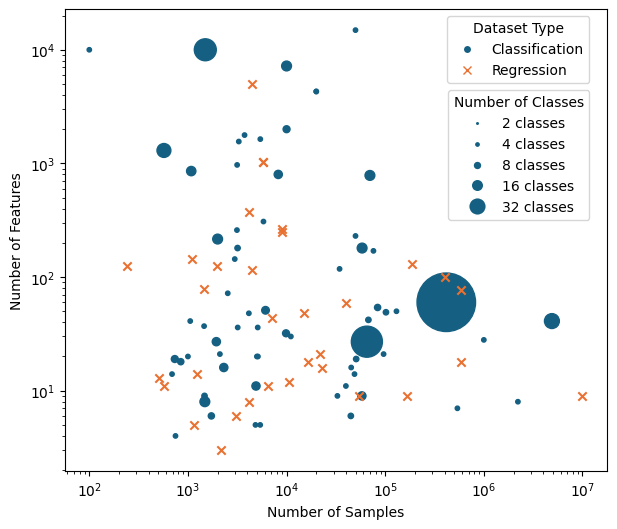

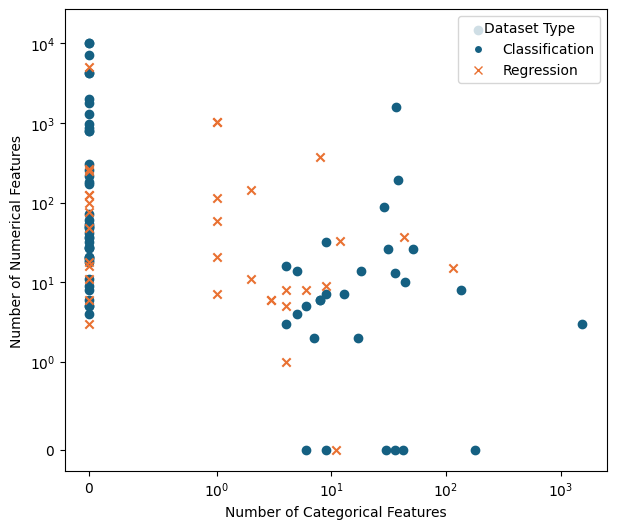

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


font = {'size': 10}

plt.rc('font', **font)

datasets = list(meta.keys())
n_samples = np.array([meta[ds]["n_samples"] for ds in datasets])
n_features = np.array([meta[ds]["n_features"] for ds in datasets])
n_classes = np.array([meta[ds].get("n_classes", -1) for ds in datasets])
n_cat = np.array([meta[ds]["n_cat"] for ds in datasets])
n_num = np.array([meta[ds]["n_num"] for ds in datasets])

type = ["classification" if n_classes[i] > 0 else "regression" for i in range(len(datasets))]

colors = ["#156082", "#e97132"]

clf_idx = [i for i in range(len(datasets)) if type[i] == "classification"]
reg_idx = [i for i in range(len(datasets)) if type[i] == "regression"]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(n_samples[clf_idx], n_features[clf_idx],
              s=n_classes[clf_idx] * 5,
              color=colors[0], marker='o', label='Classification')

ax.scatter(n_samples[reg_idx], n_features[reg_idx],
              color=colors[1], marker='x', label='Regression')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Number of Samples")
ax.set_ylabel("Number of Features")

type_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[0], markersize=6, label='Classification'),
    Line2D([0], [0], marker='x', color='w',
           markeredgecolor=colors[1], markersize=6, label='Regression'),
]

sizes = [2, 4, 8, 16, 32]
size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[0], markersize=np.sqrt(s * 5),
           label=f"{s} classes")
    for s in sizes
]

# First legend: Dataset Type
first_legend = ax.legend(
    handles=type_legend,
    title="Dataset Type",
    loc="upper right",
    bbox_to_anchor=(0.98, 1.0)
)
ax.add_artist(first_legend)

ax.legend(
    handles=size_legend,
    title="Number of Classes",
    loc="upper right",
    bbox_to_anchor=(.98, 0.84) 
)
plt.savefig("./figures/dataset_meta_1.pdf")

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(n_cat[clf_idx], n_num[clf_idx],
              color=colors[0], marker='o', label='Classification')

ax.scatter(n_cat[reg_idx], n_num[reg_idx],
              color=colors[1], marker='x', label='Regression')

ax.set_xlabel("Number of Categorical Features")
ax.set_ylabel("Number of Numerical Features")
ax.set_xscale('symlog', linthresh=1)
ax.set_yscale('symlog', linthresh=1)

ax.legend(handles=type_legend, title="Dataset Type", loc="upper right")

#plt.show()
plt.savefig("./figures/dataset_meta_2.pdf")